<a href="https://colab.research.google.com/github/jamie07262/INFO-3608-PROJECT/blob/main/XGBoostWithNewDataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import requests
import re
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss
import matplotlib.pyplot as plt

In [37]:
import os
import requests

# GitHub API URL for the directory
api_url = "https://api.github.com/repos/jamie07262/INFO-3608-PROJECT/contents/data/processed"

# Create local directory
os.makedirs("processed", exist_ok=True)

# Get list of files from GitHub API
response = requests.get(api_url)
if response.status_code == 200:
    files = response.json()
    for file in files:
        if file['name'].endswith('.csv'):
            download_url = file['download_url']
            r = requests.get(download_url)
            with open(f"processed/{file['name']}", "wb") as f:
                f.write(r.content)
            print(f"Downloaded: {file['name']}")
else:
    print(f"Failed to access API: {response.status_code}")

print("All CSV files downloaded.")

Downloaded: Features.csv
Downloaded: NewFeaturesForPredictions.csv
Downloaded: Predictions.csv
All CSV files downloaded.


In [38]:
df = pd.read_csv("processed/NewFeaturesForPredictions.csv")
df_features = df.copy()

Holdout Season: 2003
Season 2003: 0.7313432835820896 0.5274057537626927 0.26865671641791045
Holdout Season: 2004
Season 2004: 0.6791044776119403 0.5775915637874622 0.3208955223880597
Holdout Season: 2005
Season 2005: 0.6940298507462687 0.559755947364312 0.30597014925373134
Holdout Season: 2006
Season 2006: 0.7307692307692307 0.4786355157667577 0.2692307692307692
Holdout Season: 2007
Season 2007: 0.7192307692307692 0.5412072586123473 0.28076923076923077
Holdout Season: 2008
Season 2008: 0.7 0.5480683978155381 0.3
Holdout Season: 2009
Season 2009: 0.7538461538461538 0.5161657448196928 0.24615384615384617
Holdout Season: 2010
Season 2010: 0.6807692307692308 0.5510734563941678 0.3192307692307692
Holdout Season: 2011
Season 2011: 0.7884615384615384 0.49421006487960417 0.21153846153846154
Holdout Season: 2012
Season 2012: 0.7538461538461538 0.5244362177645113 0.24615384615384617
Holdout Season: 2013
Season 2013: 0.6961538461538461 0.535959893057057 0.3038461538461538
Holdout Season: 2014
Sea

,Season,Accuracy,LogLoss,Brier Score
0,2003,0.731343,0.527406,0.268657
1,2004,0.679104,0.577592,0.320896
2,2005,0.694030,0.559756,0.305970
3,2006,0.730769,0.478636,0.269231
4,2007,0.719231,0.541207,0.280769
5,2008,0.700000,0.548068,0.300000
6,2009,0.753846,0.516166,0.246154
7,2010,0.680769,0.551073,0.319231
8,2011,0.788462,0.494210,0.211538
9,2012,0.753846,0.524436,0.246154



Average Accuracy: 0.7157
Average Log Loss: 0.5353
Average Brier Score: 0.2843


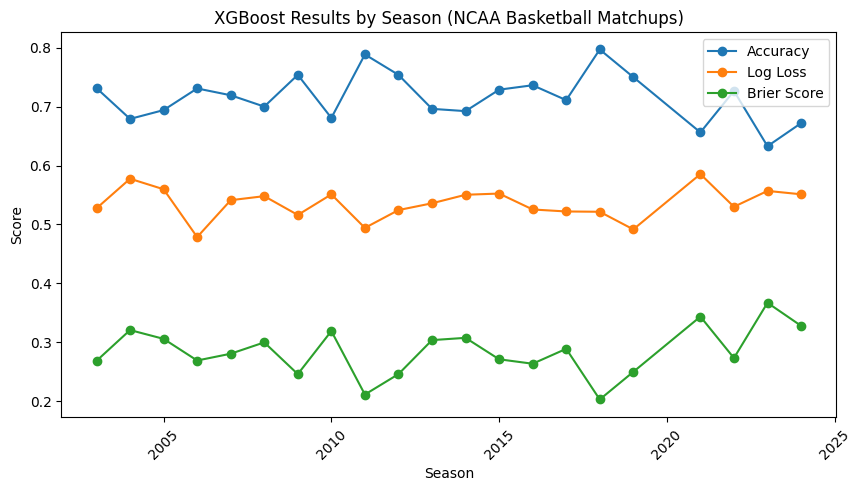

In [39]:
# FEATURES = [
#     # 'Season', 'T1TeamID', 'T2TeamID',
#         'T1AverageScore', 'T2AverageScore',
#     # 'PointDifference',
#       #       'T1Seed', 'T2Seed', 'SeedDifference',
#       #   'T1Rating', 'T2Rating', 'RatingDifference',
#       #       'T1Grade', 'T2Grade', 'GradeDifference',
#        'Divison',
#             # 'DivisonLabel',
#             # 'Win',
#             # 'WinLabel',
#        'T1AverageFGM',
#        'T1AverageFGA', 'T1AverageFGM3', 'T1AverageFGA3', 'T1AverageFTM',
#        'T1AverageFTA', 'T1AverageOR', 'T1AverageDR', 'T1AverageAst',
#        'T1AverageTO', 'T1AverageStl', 'T1AverageBlk', 'T1AveragePF',
#        'T1AverageOpponentScore', 'T1AverageOpponentFGM',
#        'T1AverageOpponentFGA', 'T1AverageOpponentFGM3',
#        'T1AverageOpponentFGA3', 'T1AverageOpponentFTM', 'T1AverageOpponentFTA',
#        'T1AverageOpponentOR', 'T1AverageOpponentDR', 'T1AverageOpponentAst',
#        'T1AverageOpponentTO', 'T1AverageOpponentStl', 'T1AverageOpponentBlk',
#        'T1AverageOpponentPF', 'T1AveragePointDifference',
#         'T2AverageFGM',
#        'T2AverageFGA', 'T2AverageFGM3', 'T2AverageFGA3', 'T2AverageFTM',
#        'T2AverageFTA', 'T2AverageOR', 'T2AverageDR', 'T2AverageAst',
#        'T2AverageTO', 'T2AverageStl', 'T2AverageBlk', 'T2AveragePF',
#        'T2AverageOpponentScore', 'T2AverageOpponentFGM',
#        'T2AverageOpponentFGA', 'T2AverageOpponentFGM3',
#        'T2AverageOpponentFGA3', 'T2AverageOpponentFTM', 'T2AverageOpponentFTA',
#        'T2AverageOpponentOR', 'T2AverageOpponentDR', 'T2AverageOpponentAst',
#        'T2AverageOpponentTO', 'T2AverageOpponentStl', 'T2AverageOpponentBlk',
#        'T2AverageOpponentPF', 'T2AveragePointDifference']
FEATURES = ["Divison", "T1Seed", "T2Seed", "SeedDifference",
            "T1AverageScore", "T1AverageFGA", "T1AverageOR", "T1AverageDR",
            "T1AverageBlk", "T1AveragePF", "T1AverageOpponentFGA",
            "T1AverageOpponentBlk", "T1AverageOpponentPF",
            "T1AveragePointDifference",
            "T2AverageScore", "T2AverageFGA", "T2AverageOR", "T2AverageDR",
            "T2AverageBlk", "T2AveragePF", "T2AverageOpponentFGA", "T2AverageOpponentBlk", "T2AverageOpponentPF", "T2AveragePointDifference",
            "T1Rating", "T2Rating", "RatingDifference", "T1Grade", "T2Grade" ]
# features = [ "men_women", "T1_seed", "T2_seed",
#                    "Seed_diff", "T1_avg_Score", "T1_avg_FGA",
#                     "T1_avg_OR", "T1_avg_DR", "T1_avg_Blk", "T1_avg_PF",
#                     "T1_avg_opponent_FGA", "T1_avg_opponent_Blk", "T1_avg_opponent_PF",
#                     "T1_avg_PointDiff", "T2_avg_Score", "T2_avg_FGA", "T2_avg_OR", "T2_avg_DR",
#                     "T2_avg_Blk", "T2_avg_PF", "T2_avg_opponent_FGA", "T2_avg_opponent_Blk",
#                     "T2_avg_opponent_PF", "T2_avg_PointDiff", "T1_elo", "T2_elo", "elo_diff",
#                     "T1_quality", "T2_quality", ]
TARGET = "Win"

# Prepare data
x = df_features[FEATURES]
y = df_features[TARGET]
groups = df_features["Season"]
seasons = df_features["Season"].unique()

# Set up GroupKFold for cross-validation by season
gkf = GroupKFold(n_splits=len(seasons))

# Store results and models
cv_results = []
models = []


# Cross-validation loop
for season_idx, (train_index, test_index) in enumerate(gkf.split(x, y, groups)):
    holdout_season = seasons[season_idx]
    x_train, x_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Define model
    model = xgb.XGBRegressor(
        eval_metric="logloss",
        n_estimators = 1337,
        learning_rate=0.001,
    )

    holdout_season = seasons[season_idx]
    print(f"Holdout Season: {holdout_season}")

    # Train model
    model.fit(
        x_train,
        y_train,
        eval_set=[(x_test, y_test)],
        verbose = 0,
    )

    # Predict probabilities and class labels
    y_pred = model.predict(x_test)
    score_ll = log_loss(y_test, y_pred)
    y_pred = y_pred > 0.5

    # Evaluate performance
    accuracy = accuracy_score(y_test, y_pred)

    brier_score = brier_score_loss(y_test, y_pred)

    # Store results
    cv_results.append({
        "Season": holdout_season,
        "Accuracy": accuracy,
        "LogLoss": score_ll,
        "Brier Score": brier_score,
    })

    season_idx += 1
    print(f"Season {holdout_season}: {accuracy} {score_ll} {brier_score}")

    models.append(model)

# Display cross-validation results
df_cv_results = pd.DataFrame(cv_results)
display(df_cv_results)
print(f"\nAverage Accuracy: {df_cv_results['Accuracy'].mean():.4f}")
print(f"Average Log Loss: {df_cv_results['LogLoss'].mean():.4f}")
print(f"Average Brier Score: {df_cv_results['Brier Score'].mean():.4f}")

# Optional: Plot the results by season
plt.figure(figsize=(10, 5))
plt.plot(df_cv_results['Season'], df_cv_results['Accuracy'], marker='o', label='Accuracy')
plt.plot(df_cv_results['Season'], df_cv_results['LogLoss'], marker='o', label='Log Loss')
plt.plot(df_cv_results['Season'], df_cv_results['Brier Score'], marker='o', label='Brier Score')
plt.xlabel("Season")
plt.ylabel("Score")
plt.title("XGBoost Results by Season (NCAA Basketball Matchups)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [40]:
from itertools import product


teams = pd.unique(df[["T1TeamID", "T2TeamID"]].values.ravel())


matchups = set()
year = 2025

for t1, t2 in product(teams, repeat=2):
    if t1 != t2:
        low, high = sorted([t1, t2])
        matchups.add(f"{year}_{low}_{high}")


print(len(matchups))
matchups = list(matchups)
matchups = sorted(matchups)
print(matchups[121277])

121278
2025_3462_3465


In [41]:
print((df[df['T1TeamID'] == 3479] | df['T2TeamID'] == 3479))

Empty DataFrame
Columns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]
Index: []

[0 rows x 4627 columns]
